# Research Questions Analysis — Restaurant Ratings (Milan)

**Pipeline Stage 7 — Analysis & results.** Read-only analytics over the flat
ClickHouse tables produced by `dataman-load-clickhouse`.

This notebook answers the project's research questions — **4 main + 3 secondary**
(README §1) plus **4 extended, feature-driven** questions — one section each: the SQL,
the rendered result, interactive charts, and a written answer. Result tables are exported
to `report/final/tables/` as **CSV + LaTeX** for the final report.

### Prerequisites
1. Start the analytics layer: `docker compose --profile analytics up -d clickhouse`
2. Load the data: `uv run dataman-load-clickhouse all`
   *(this notebook relies on the extended `restaurants_integrated` schema — per-platform
   photo counts, contact-completeness flags, cuisines and `price_tier`; if you changed the
   loader, drop & reload: `DROP TABLE restaurants_integrated` then reload).*
3. Install notebook deps: `uv sync --extra analysis`
4. Run top to bottom (or `uv run jupyter nbconvert --to notebook --execute --inplace notebooks/research_questions_analysis.ipynb`).

> **Read-only.** Every query is a `SELECT`; the notebook performs no writes, DDL or
> truncation against ClickHouse or MongoDB.

In [1]:
from __future__ import annotations

import os

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio

from analysis import queries
from analysis.config import AnalysisSettings, clickhouse_client
from analysis.constants import CENTER_RADIUS_KM, SPARSE_REVIEW_THRESHOLD
from analysis.export import to_csv, to_latex
from analysis.geo import assign_neighbourhood, classify_center_periphery

# Static PNG by default so charts render everywhere: VS Code, GitHub's notebook
# viewer (which strips JavaScript, so interactive Plotly never shows there), and
# the exported HTML. Set DATAMAN_PLOTLY_RENDERER=notebook_connected to build an
# *interactive* HTML instead.
pio.renderers.default = os.environ.get("DATAMAN_PLOTLY_RENDERER", "png")
pd.set_option("display.max_columns", None)

settings = AnalysisSettings()
client = clickhouse_client(settings)  # clear error if ClickHouse is unreachable


def run(sql: str) -> pd.DataFrame:
    """Execute a read-only SELECT and return a pandas DataFrame."""
    return client.query_df(sql)


def publish(df: pd.DataFrame, name: str, caption: str) -> pd.DataFrame:
    """Export a result table to CSV + LaTeX under report/final/tables/ and return it."""
    to_csv(df, name)
    to_latex(df, name, caption=caption, label=f"tab:{name}")
    return df


print(f"Connected to ClickHouse db='{settings.clickhouse_db}' at "
      f"{settings.clickhouse_host}:{settings.clickhouse_port}")

Connected to ClickHouse db='dataman' at localhost:8123


## Methodology & data structure

Two facts shape every cross-platform comparison below:

1. **Google is the seed.** Every integrated restaurant has a Google record; Tripadvisor
   and TheFork are matched onto it. So the meaningful comparisons are the *pairs*
   **Google–Tripadvisor**, **Google–TheFork**, and (only within the all-three set)
   **Tripadvisor–TheFork**. We report consistency **pairwise** rather than as one blob,
   because TheFork's coverage (~0.9k matched venues) is an order of magnitude smaller than
   Tripadvisor's (~3.9k).
2. **"Total reviews" is not a clean popularity measure.** Summing review counts across
   platforms mixes three different, overlapping user bases and silently treats a missing
   platform as zero. Where a single popularity proxy is needed we use the **Google review
   count** (widest, most complete coverage) and say so; combined sums are avoided.

Consistency metrics use only venues rated on **≥ 2 platforms** (`rating_platform_count >= 2`).

In [2]:
coverage = run(queries.q0_platform_coverage())
publish(coverage, "q0_platform_coverage", "Platform co-occurrence across integrated restaurants.")
coverage

,has_google,has_tripadvisor,has_thefork,restaurants
0,1,0,0,5967
1,1,1,0,3179
2,1,1,1,745
3,1,0,1,163


## Q1 — How consistent are ratings across platforms?

Distribution of the rating spread plus **pairwise** agreement. Multiple views: a summary
(overall and split by 2- vs 3-platform coverage), the spread histogram, cumulative
tolerance bands, and per-pair agreement.

In [3]:
q1_sum = publish(run(queries.q1_summary()), "q1_consistency_summary",
                 "Q1 — Rating-spread summary, overall and by platform coverage.")
q1_sum

,coverage,restaurants,mean_range,sd_range,p90_range,max_range,pct_within_0_5,pct_within_1_0
0,,4070,0.518,0.478,1.1,3.80,65.1,89.6
1,2,3341,0.515,0.502,1.1,3.80,66.6,89.1
2,3,729,0.537,0.346,1.0,2.35,57.9,92.2


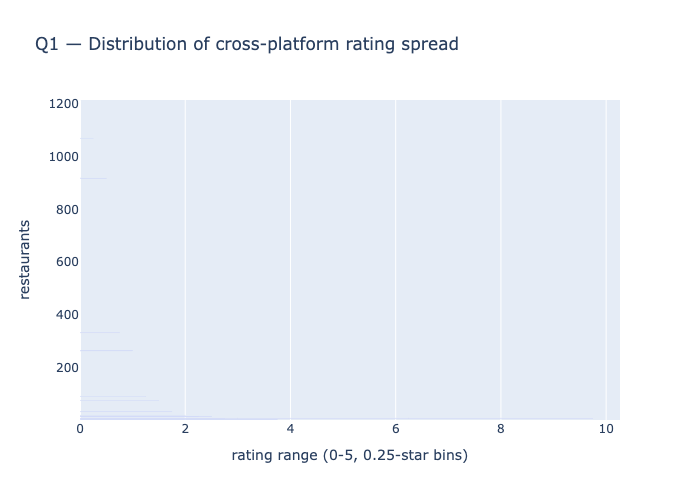

In [4]:
q1_hist = run(queries.q1_histogram())
fig = px.bar(q1_hist, x="range_bin", y="restaurants",
             labels={"range_bin": "rating range (0-5, 0.25-star bins)", "restaurants": "restaurants"},
             title="Q1 — Distribution of cross-platform rating spread")
fig.show()

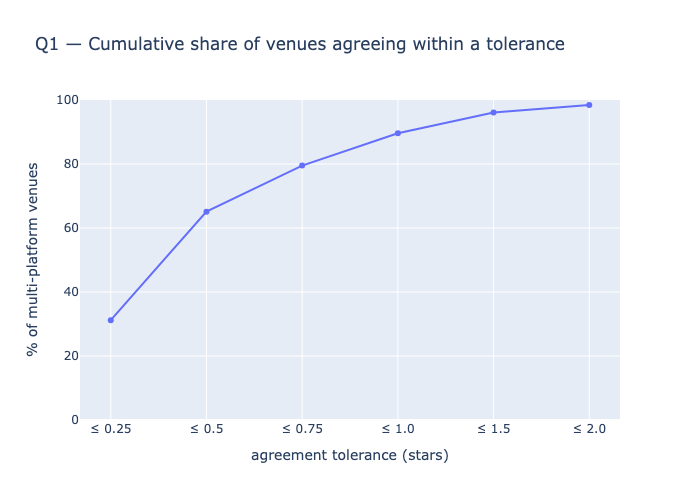

In [5]:
bands = run(queries.q1_tolerance_bands())
band_long = bands.drop(columns=["multi_platform_restaurants"]).T.reset_index()
band_long.columns = ["band", "pct_within"]
band_long["band"] = band_long["band"].str.replace("within_", "≤ ").str.replace("_", ".")
fig = px.line(band_long, x="band", y="pct_within", markers=True,
              labels={"band": "agreement tolerance (stars)", "pct_within": "% of multi-platform venues"},
              title="Q1 — Cumulative share of venues agreeing within a tolerance")
fig.update_yaxes(range=[0, 100])
fig.show()

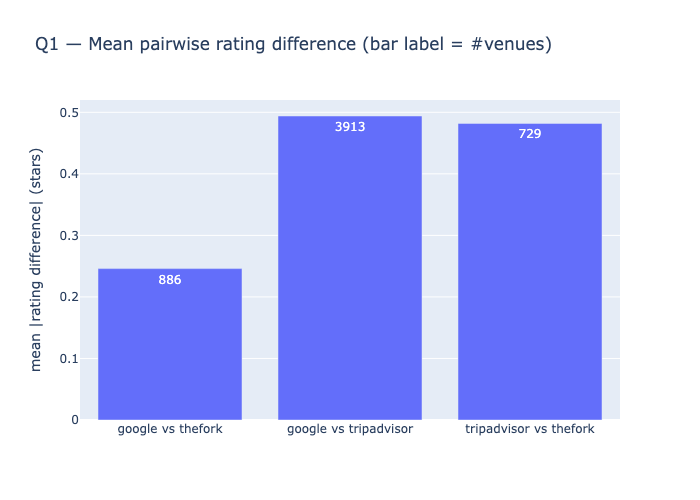

,pair,venues,mean_abs_diff,median_abs_diff,pct_within_0_5,pct_within_1_0
0,google vs thefork,886,0.246,0.2,92.7,99.2
1,google vs tripadvisor,3913,0.494,0.4,66.9,89.9
2,tripadvisor vs thefork,729,0.482,0.4,62.0,92.3


In [6]:
q1_pair = publish(run(queries.q1_pairwise_agreement()), "q1_pairwise_agreement",
                  "Q1 — Pairwise agreement (mean |diff| and tolerance shares) per platform pair.")
fig = px.bar(q1_pair, x="pair", y="mean_abs_diff", text="venues",
             labels={"pair": "", "mean_abs_diff": "mean |rating difference| (stars)"},
             title="Q1 — Mean pairwise rating difference (bar label = #venues)")
fig.show()
q1_pair

**Answer (Q1):** Most multi-platform venues agree closely — see `q1_consistency_summary`
(`pct_within_0_5`, `pct_within_1_0`). But agreement is **pair-dependent**: Google and
TheFork agree very tightly, whereas Google–Tripadvisor and Tripadvisor–TheFork disagree
noticeably more (`q1_pairwise_agreement`). Tripadvisor is the source that most often pulls
a venue's ratings apart.

## Q2 — Which restaurants disagree the most? (pairwise)

Because the pairs rest on very different sample sizes, the biggest disagreers are listed
**per pair** (Google vs Tripadvisor, Google vs TheFork) and for the all-three set, rather
than pooled. This reproduces and extends the README's mandatory *"rating difference > 1
star"* query.

In [7]:
q2_gta = publish(run(queries.q2_top_pair("google", "tripadvisor", top_n=20, min_diff=1.0)),
                 "q2_top_google_vs_tripadvisor",
                 "Q2 — Largest Google vs Tripadvisor rating gaps (>1 star).")
q2_gta

,canonical_name,canonical_city,google_rating,tripadvisor_rating,abs_diff,google_reviews,tripadvisor_reviews
0,SUSHI NIKKEI Duomo San Babila Milano - Restaur...,Milano,4.7,1.0,3.7,87,1
1,Villa,Milano,4.6,1.0,3.6,70,1
2,Osteria San Giovanni - Ristorante Pugliese,Milano,4.6,1.0,3.6,101,1
3,Silia Pizza al Trancio,Milano,4.5,1.0,3.5,274,1
4,Poke House - Nirone,Milano,4.5,1.0,3.5,329,2
5,Il Buon Pane,Milano,4.5,1.0,3.5,80,1
6,Pizzeria S. Stefano,Milano,4.5,1.0,3.5,152,1
7,Vino,Milano,4.4,1.0,3.4,314,2
8,Vibes cocktail bar,Milano,4.4,1.0,3.4,258,2
9,Cento Caffè caffetteria,Milano,4.4,1.0,3.4,511,1


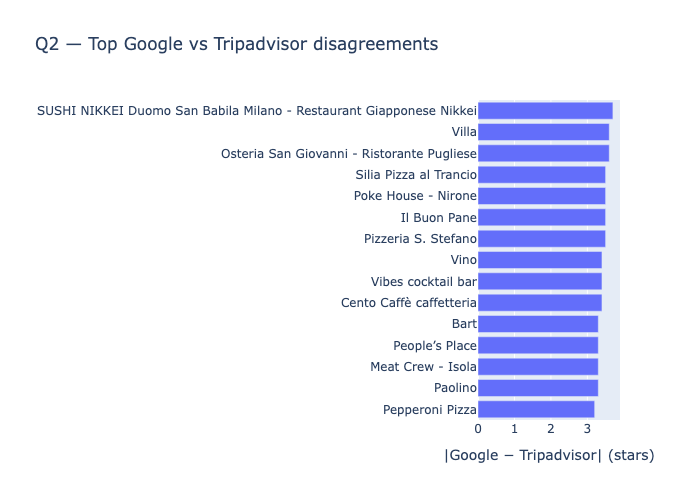

In [8]:
if not q2_gta.empty:
    top = q2_gta.head(15)[::-1]
    fig = px.bar(top, x="abs_diff", y="canonical_name", orientation="h",
                 hover_data=["canonical_city", "google_rating", "tripadvisor_rating"],
                 labels={"abs_diff": "|Google − Tripadvisor| (stars)", "canonical_name": ""},
                 title="Q2 — Top Google vs Tripadvisor disagreements")
    fig.show()

In [9]:
q2_gtf = publish(run(queries.q2_top_pair("google", "thefork", top_n=20, min_diff=1.0)),
                 "q2_top_google_vs_thefork",
                 "Q2 — Largest Google vs TheFork rating gaps (>1 star).")
q2_gtf

,canonical_name,canonical_city,google_rating,thefork_rating,abs_diff,google_reviews,thefork_reviews
0,Tasty Bite Cucina Indiana,Milano,4.8,1.00,3.80,37,<NA>
1,Mia Poke,Milano,4.4,1.65,2.75,43,3
2,Archie’s - Comida Peruviana,Milano,4.4,2.15,2.25,204,5
3,Il francolino Pizzeria / Bar,Milano,4.5,3.00,1.50,10,<NA>
4,Solar Grill,Milano,2.9,4.20,1.30,19,118
5,Spadari Restaurant,Milano,2.8,3.90,1.10,815,6
6,Benza,Milano,3.9,2.85,1.05,203,191


In [10]:
q2_all = publish(run(queries.q2_top_all_three(top_n=20)), "q2_top_all_three",
                 "Q2 — Largest full-range disagreements among all-three-platform venues.")
q2_all

,canonical_name,canonical_city,google_rating_5,tripadvisor_rating_5,thefork_rating_5,rating_range_5
0,Ristorante Pesce D'amare,Milano,4.3,2.0,4.35,2.35
1,Pizza Garage,Milano,4.1,2.1,4.40,2.30
2,SANCEN RISTORANTE CINESE (SHANCHENG) 山城小灶,Milano,4.8,3.1,5.00,1.90
3,Salotto Brera,Milano,4.4,2.5,4.15,1.90
4,Osteria delle Coppelle Milano,Milano,3.5,2.4,4.20,1.80
5,Sandì,Milano,4.7,3.0,4.65,1.70
6,Trattoria dell'Arco,Milano,4.7,3.0,4.35,1.70
7,Gòodurie Soresina,Milano,4.3,2.6,4.25,1.70
8,Ci Sta - Buenos Aires,Milano,4.3,2.8,4.40,1.60
9,La Jungle De Plein - Bistrot & Garden,Milano,4.6,3.0,4.00,1.60


**Answer (Q2):** The worst disagreements are dominated by the Google–Tripadvisor pair
(largest sample, widest gaps). `q2_top_google_vs_thefork` is much shorter — few venues are
on both Google and TheFork *and* disagree by >1 star, consistent with Q1's finding that
those two platforms largely agree. The per-platform columns show which source is the
outlier in each case.

## Q3 — Is inconsistency linked to data-quality issues?

Relates disagreement to **review volume** and **platform coverage**, reporting the
mandatory *correlation between review count and rating variance*. Everything is split by
2- vs 3-platform coverage, since a 3-platform max−min range is mechanically wider than a
2-platform one — pooling them would confound the two.

> **Timeliness limitation.** "Outdated information" cannot be measured from ClickHouse:
> there is no per-record collection timestamp (`updated_at` is load time, identical across
> rows). We answer the data-quality link with review-volume and coverage proxies and flag
> timeliness as out of reach for this schema.

In [11]:
q3_corr = publish(run(queries.q3_correlations()), "q3_correlations",
                  "Q3 — Correlation of rating spread with review volume, by coverage.")
q3_corr

,coverage,venues,corr_range_least_reviews,corr_range_total_reviews
0,,4070,-0.128,-0.073
1,2,3341,-0.137,-0.099
2,3,729,-0.049,-0.015


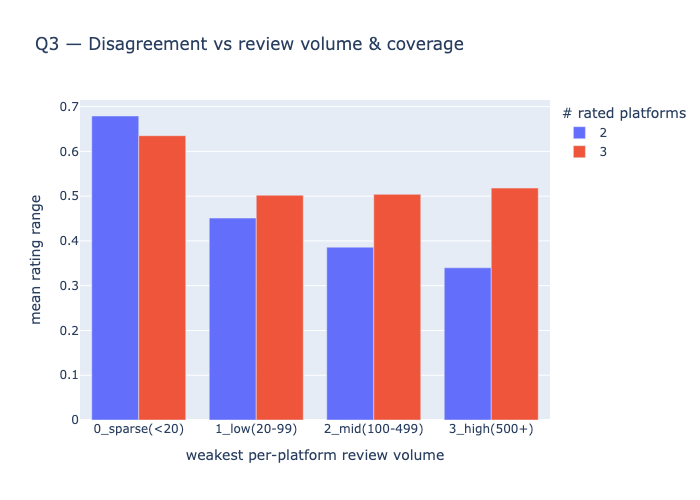

,coverage,min_reviews_bucket,restaurants,mean_range
0,2,0_sparse(<20),1362,0.679
1,2,1_low(20-99),766,0.451
2,2,2_mid(100-499),782,0.386
3,2,3_high(500+),431,0.340
4,3,0_sparse(<20),171,0.635
5,3,1_low(20-99),213,0.502
6,3,2_mid(100-499),220,0.504
7,3,3_high(500+),125,0.518


In [12]:
q3_bin = publish(run(queries.q3_binned()), "q3_disagreement_by_reviews",
                 "Q3 — Mean rating spread by weakest-review bucket and coverage.")
fig = px.bar(q3_bin, x="min_reviews_bucket", y="mean_range", color="coverage", barmode="group",
             labels={"min_reviews_bucket": "weakest per-platform review volume",
                     "mean_range": "mean rating range", "coverage": "# rated platforms"},
             title="Q3 — Disagreement vs review volume & coverage")
fig.show()
q3_bin

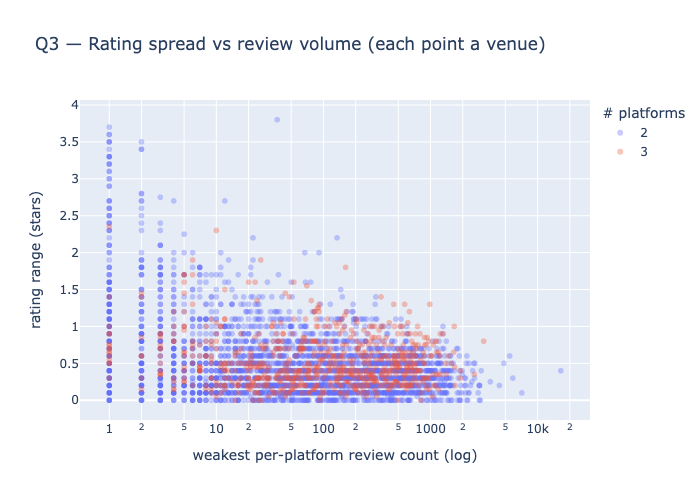

In [13]:
scatter = run(queries.q3_scatter_rows())
fig = px.scatter(scatter, x="least_reviews", y="rating_range_5", color="coverage",
                 opacity=0.35, log_x=True,
                 labels={"least_reviews": "weakest per-platform review count (log)",
                         "rating_range_5": "rating range (stars)", "coverage": "# platforms"},
                 title="Q3 — Rating spread vs review volume (each point a venue)")
fig.show()

**Answer (Q3):** The correlation between rating spread and review volume is **negative
but weak** (`q3_correlations`): venues whose weakest platform has few reviews disagree
somewhat more, so inconsistency is *partly* a data-quality artefact — but review volume is
far from the whole story. The effect is clearer for 2-platform venues than 3-platform ones.
Timeliness is not assessable from the current schema (noted above).

## Q4 — Can sparse data inflate perceived quality?

Compares per-platform ratings of **sparse** venues (review count < 20, README §4) against
well-reviewed ones. If sparse venues average higher, thin evidence inflates perceived
quality. Null ratings/counts are excluded per platform.

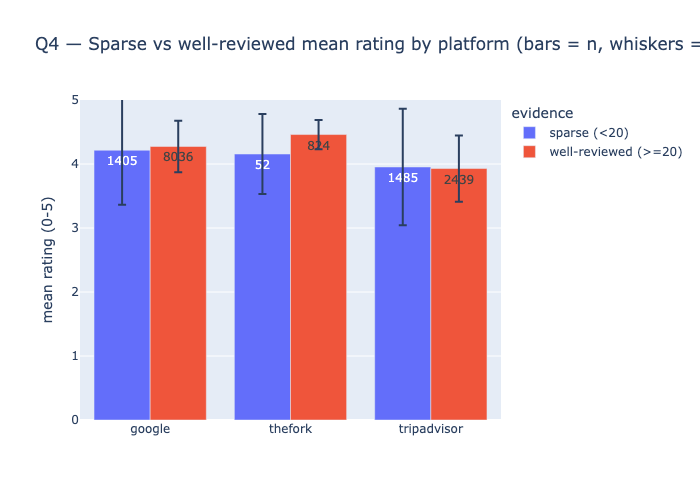

,platform,bucket,restaurants,mean_rating,sd_rating
0,google,sparse (<20),1405,4.215,0.851
1,google,well-reviewed (>=20),8036,4.274,0.402
2,thefork,sparse (<20),52,4.156,0.624
3,thefork,well-reviewed (>=20),824,4.460,0.228
4,tripadvisor,sparse (<20),1485,3.953,0.911
5,tripadvisor,well-reviewed (>=20),2439,3.929,0.517


In [14]:
q4 = publish(run(queries.q4_sparse_summary()), "q4_sparse_inflation",
             "Q4 — Mean rating of sparse (<20 reviews) vs well-reviewed venues, per platform.")
fig = px.bar(q4, x="platform", y="mean_rating", color="bucket", barmode="group",
             error_y="sd_rating", text="restaurants",
             labels={"mean_rating": "mean rating (0-5)", "platform": "", "bucket": "evidence"},
             title="Q4 — Sparse vs well-reviewed mean rating by platform (bars = n, whiskers = SD)")
fig.update_yaxes(range=[0, 5])
fig.show()
q4

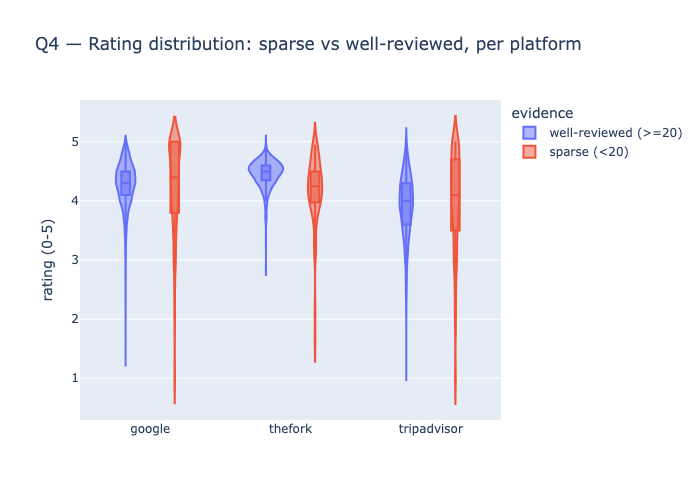

In [15]:
dist = run(queries.q4_rating_rows())
fig = px.violin(dist, x="platform", y="rating", color="bucket", box=True, points=False,
                labels={"rating": "rating (0-5)", "platform": "", "bucket": "evidence"},
                title="Q4 — Rating distribution: sparse vs well-reviewed, per platform")
fig.show()

**Answer (Q4):** Compare the `sparse (<20)` and `well-reviewed (>=20)` means per
platform. A consistently higher sparse mean — most visible on the larger Google and
Tripadvisor samples — is direct evidence that low-volume data inflates perceived quality;
the violins show sparse venues also have heavier high-rating tails.

## Q5 — Are some platforms systematically optimistic/pessimistic?

**How is the baseline set?** A naive bias = *rating − mean of all platforms* is biased
toward zero because the platform is part of its own baseline. We therefore report several
established measures and compare them:

- **Raw mean rating** per platform (uncontrolled).
- **Leave-one-out (LOO) deviation** — each rating minus the consensus of the *other*
  platforms only. This is the cleanest signed-bias measure (no self-inclusion).
- **Pairwise signed differences** (A − B over venues on both) — model-free and symmetric.

(A two-way fixed-effects model *rating ~ restaurant + platform* would give an equivalent
platform effect; with at most three platforms the LOO/pairwise measures capture the same
signal without the extra machinery.)

In [16]:
rows = run(queries.q5_platform_rows())
cols = {"google": "google_rating_5", "tripadvisor": "tripadvisor_rating_5", "thefork": "thefork_rating_5"}

bias = []
for p, c in cols.items():
    others = [oc for op, oc in cols.items() if op != p]
    present = rows[rows[c].notna()]
    consensus_loo = present[others].mean(axis=1)            # mean of the OTHER platforms
    bias.append({
        "platform": p,
        "rated_venues": int(present[c].notna().sum()),
        "mean_rating": round(present[c].mean(), 3),
        "loo_deviation": round((present[c] - consensus_loo).mean(), 3),
        "dev_from_consensus": round((present[c] - present["rating_avg_5"]).mean(), 3),
    })
q5_bias = publish(pd.DataFrame(bias), "q5_platform_bias",
                  "Q5 — Platform bias: raw mean, leave-one-out deviation, deviation from consensus.")
q5_bias

,platform,rated_venues,mean_rating,loo_deviation,dev_from_consensus
0,google,4070,4.296,0.308,0.157
1,tripadvisor,3913,3.939,-0.362,-0.191
2,thefork,886,4.437,0.180,0.122


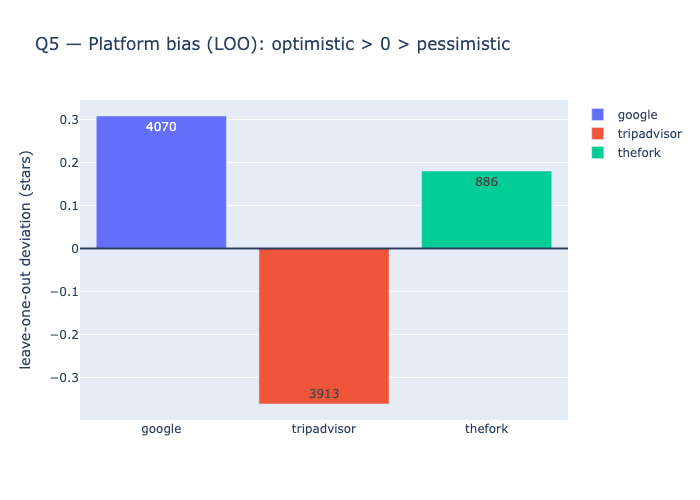

In [17]:
fig = px.bar(q5_bias, x="platform", y="loo_deviation", color="platform", text="rated_venues",
             labels={"loo_deviation": "leave-one-out deviation (stars)", "platform": ""},
             title="Q5 — Platform bias (LOO): optimistic > 0 > pessimistic")
fig.add_hline(y=0)
fig.show()

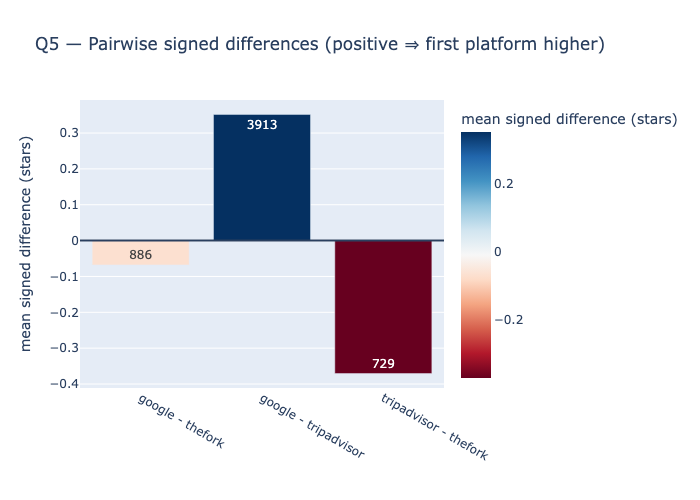

,pair,venues,mean_signed_diff
0,google - thefork,886,-0.068
1,google - tripadvisor,3913,0.352
2,tripadvisor - thefork,729,-0.371


In [18]:
q5_pair = publish(run(queries.q5_pairwise_differences()), "q5_pairwise_differences",
                  "Q5 — Mean signed rating difference per ordered platform pair (A − B).")
fig = px.bar(q5_pair, x="pair", y="mean_signed_diff", color="mean_signed_diff",
             color_continuous_scale="RdBu", text="venues",
             labels={"mean_signed_diff": "mean signed difference (stars)", "pair": ""},
             title="Q5 — Pairwise signed differences (positive ⇒ first platform higher)")
fig.add_hline(y=0)
fig.show()
q5_pair

**Answer (Q5):** All three measures agree on the ordering. **Tripadvisor is
systematically the most pessimistic** (negative LOO deviation; Google − Tripadvisor and
TheFork − Tripadvisor both positive), while **TheFork rates highest** and Google sits in
between. The agreement of the raw, LOO and pairwise measures makes the direction robust to
how the baseline is defined.

## Q6 — Does inconsistency increase for less popular restaurants?

Bins multi-platform venues by **Google review count** (widest, most complete popularity
signal) and reports the **mean** spread per bin with its standard error. Median is
deliberately dropped: with at most three platforms a per-venue range is the max−min of ≤3
values, so a binned median snaps to a few discrete values and tells no story — the mean
(with a confidence band) does.

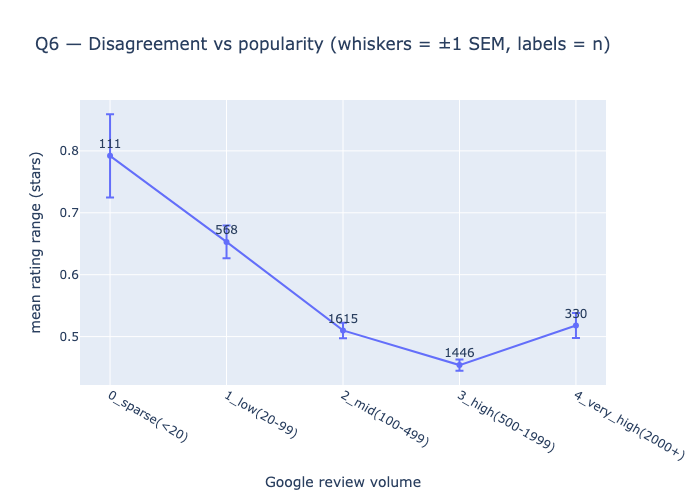

,popularity_bin,restaurants,mean_range,sd_range,sem
0,0_sparse(<20),111,0.792,0.708,0.067200
1,1_low(20-99),568,0.653,0.629,0.026392
2,2_mid(100-499),1615,0.510,0.502,0.012492
3,3_high(500-1999),1446,0.454,0.348,0.009152
4,4_very_high(2000+),330,0.518,0.367,0.020203


In [19]:
q6 = run(queries.q6_popularity_bins())
q6["sem"] = q6["sd_range"] / np.sqrt(q6["restaurants"])
publish(q6, "q6_popularity_bins", "Q6 — Mean rating spread by Google-review popularity bin.")
fig = px.line(q6, x="popularity_bin", y="mean_range", error_y="sem", markers=True, text="restaurants",
              labels={"popularity_bin": "Google review volume", "mean_range": "mean rating range (stars)"},
              title="Q6 — Disagreement vs popularity (whiskers = ±1 SEM, labels = n)")
fig.update_traces(textposition="top center")
fig.show()
q6

**Answer (Q6):** Mean spread **declines as popularity rises** — the sparse/low-review
bins disagree most and the very-high bin least — so inconsistency does increase for smaller,
less-popular restaurants. The SEM band shows the trend is well-determined despite the small
high-popularity bins.

## Q7 — Does location affect data completeness?

**What counts as completeness here.** Coordinates are *not* used: Tripadvisor's were
enriched downstream by our Nominatim geocoding, so `has_coordinates` measures our pipeline,
not the platform. Instead we use platform-provided signals — **platform coverage, website
presence (Google/Tripadvisor), photo richness, and review volume**.

Three cuts, each visualised separately: an interactive **map**, a **center vs periphery**
split (≤ 2 km from the Duomo), **popular quartieri vs other**, and a **postal-code** table.

In [20]:
rows = run(queries.q7_rows())
rows["zone"] = rows.apply(lambda r: classify_center_periphery(r["latitude"], r["longitude"]), axis=1)
rows["neighbourhood"] = rows.apply(lambda r: assign_neighbourhood(r["latitude"], r["longitude"]), axis=1)
geo = rows.dropna(subset=["latitude", "longitude"])
geo = geo[(geo["latitude"] != 0) & (geo["longitude"] != 0)]
print(f"{len(rows) - len(geo)} rows without usable coordinates (excluded from maps/zone cut).")

0 rows without usable coordinates (excluded from maps/zone cut).


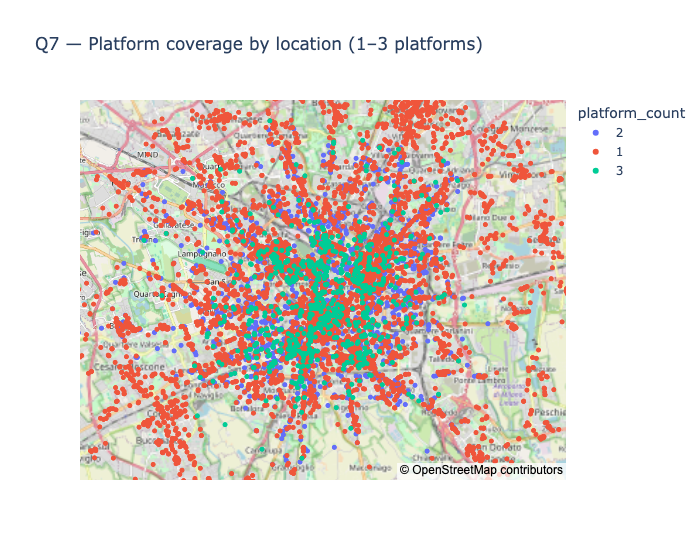

In [21]:
# Map 1 — platform coverage across the city (visual completeness signal).
fig = px.scatter_map(geo, lat="latitude", lon="longitude", color="platform_count",
                     color_continuous_scale="Viridis", zoom=10.5, height=560,
                     hover_name="name", map_style="open-street-map",
                     title="Q7 — Platform coverage by location (1–3 platforms)")
fig.show()

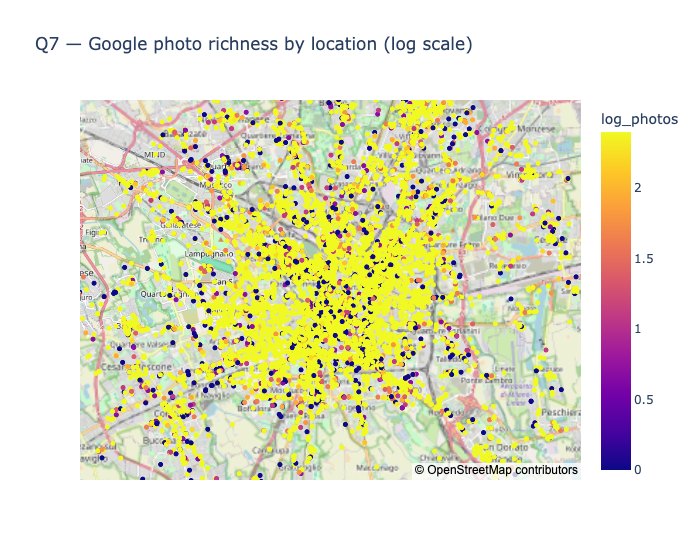

In [22]:
# Map 2 — Google photo richness (log-scaled) as a content-completeness signal.
geo2 = geo.copy()
geo2["log_photos"] = np.log1p(geo2["google_photo_count"].fillna(0))
fig = px.scatter_map(geo2, lat="latitude", lon="longitude", color="log_photos",
                     color_continuous_scale="Plasma", zoom=10.5, height=560,
                     hover_name="name", map_style="open-street-map",
                     title="Q7 — Google photo richness by location (log scale)")
fig.show()

In [23]:
def completeness_summary(df):
    g = df[df["has_google"] == 1]
    ta = df[df["has_tripadvisor"] == 1]
    return pd.Series({
        "restaurants": len(df),
        "mean_platform_count": round(df["platform_count"].mean(), 2),
        "pct_on_tripadvisor": round(100 * df["has_tripadvisor"].mean(), 1),
        "pct_on_thefork": round(100 * df["has_thefork"].mean(), 1),
        "pct_google_website": round(100 * g["google_has_website"].mean(), 1) if len(g) else None,
        "pct_ta_website": round(100 * ta["tripadvisor_has_website"].mean(), 1) if len(ta) else None,
        "mean_google_photos": round(df["google_photo_count"].fillna(0).mean(), 1),
        "median_google_reviews": float(df["google_review_count"].median()),
    })

q7_zone = geo.groupby("zone").apply(completeness_summary, include_groups=False).reset_index()
q7_zone = publish(q7_zone, "q7_completeness_center_periphery",
                  "Q7 — Completeness: center (<=2 km from Duomo) vs periphery.")
q7_zone

,zone,restaurants,mean_platform_count,pct_on_tripadvisor,pct_on_thefork,pct_google_website,pct_ta_website,mean_google_photos,median_google_reviews
0,center,2664.0,1.67,53.0,13.9,63.7,89.5,8.5,268.5
1,periphery,7390.0,1.41,34.0,7.3,48.9,81.9,8.2,154.0


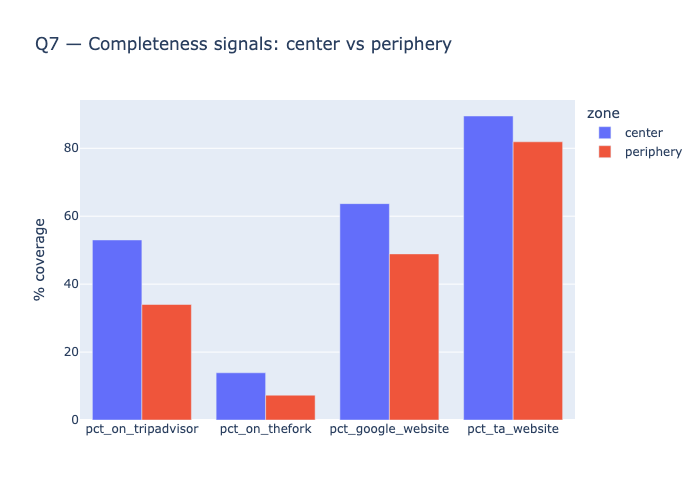

In [24]:
metrics = ["pct_on_tripadvisor", "pct_on_thefork", "pct_google_website", "pct_ta_website"]
zone_long = q7_zone.melt(id_vars="zone", value_vars=metrics, var_name="metric", value_name="pct")
fig = px.bar(zone_long, x="metric", y="pct", color="zone", barmode="group",
             labels={"pct": "% coverage", "metric": ""},
             title="Q7 — Completeness signals: center vs periphery")
fig.show()

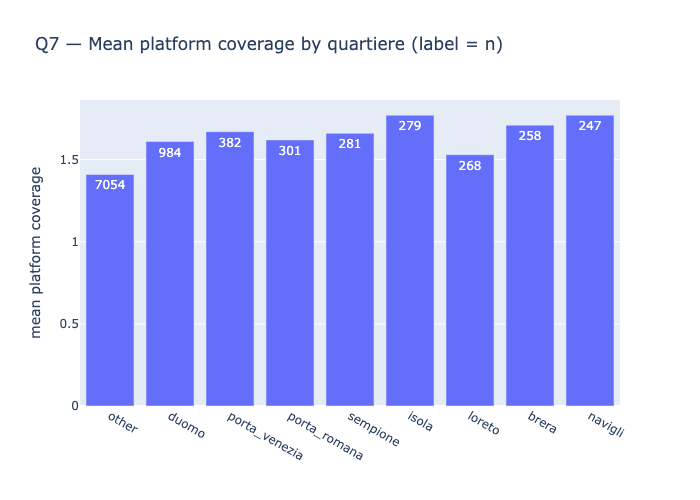

,neighbourhood,restaurants,mean_platform_count,pct_on_tripadvisor,pct_on_thefork,pct_google_website,pct_ta_website,mean_google_photos,median_google_reviews
5,other,7054.0,1.41,33.3,7.4,49.6,82.9,8.2,155.5
1,duomo,984.0,1.61,51.7,9.8,62.0,89.6,8.3,215.0
7,porta_venezia,382.0,1.67,52.9,14.4,63.9,85.6,9.0,305.5
6,porta_romana,301.0,1.62,47.5,15.0,60.1,86.7,8.6,229.0
8,sempione,281.0,1.66,50.5,15.3,51.6,81.0,8.4,180.0
2,isola,279.0,1.77,59.5,17.9,68.8,86.1,9.0,310.0
3,loreto,268.0,1.53,43.7,9.3,42.9,80.3,8.4,134.0
0,brera,258.0,1.71,55.8,15.5,60.5,92.4,7.6,345.0
4,navigli,247.0,1.77,62.3,14.2,67.6,89.0,9.2,413.0


In [25]:
q7_hood = geo.groupby("neighbourhood").apply(completeness_summary, include_groups=False).reset_index()
q7_hood = q7_hood.sort_values("restaurants", ascending=False)
q7_hood = publish(q7_hood, "q7_completeness_neighbourhood",
                  "Q7 — Completeness by popular Milan quartiere vs other.")
fig = px.bar(q7_hood, x="neighbourhood", y="mean_platform_count", text="restaurants",
             labels={"mean_platform_count": "mean platform coverage", "neighbourhood": ""},
             title="Q7 — Mean platform coverage by quartiere (label = n)")
fig.show()
q7_hood

In [26]:
q7_postal = publish(run(queries.q7_postal_completeness()), "q7_completeness_by_postal_code",
                    "Q7 — Coverage and completeness by postal code (area proxy).")
q7_postal.head(15)

,postal_code,restaurants,mean_platform_count,pct_on_tripadvisor,pct_on_thefork,pct_google_website,mean_google_photos
0,20121,591,1.71,56.2,14.9,66.7,8.1
1,20123,573,1.64,52.7,11.0,63.9,8.7
2,20154,572,1.63,48.8,14.3,51.0,8.4
3,20124,509,1.69,52.7,16.7,61.5,8.8
4,20122,465,1.58,48.6,9.9,54.6,8.0
5,20129,392,1.66,53.6,12.8,68.4,9.1
6,20135,353,1.64,49.3,14.7,66.6,8.9
7,20099,291,1.00,0.0,0.0,50.2,8.4
8,20159,288,1.75,58.7,16.7,59.7,8.9
9,20144,287,1.86,69.3,17.1,72.5,9.4


**Answer (Q7):** Central restaurants (≤ 2 km from the Duomo) and the popular quartieri
carry **fuller data** — higher platform coverage, more Google photos, and higher
Tripadvisor/TheFork presence — than peripheral areas, as the maps and the
center/periphery/quartiere tables show. Using platform-provided signals (not enriched
coordinates) keeps this an honest completeness comparison.

## Q8 — Does rating consistency or level vary by cuisine? *(extended)*

Groups venues by `primary_cuisine` (Tripadvisor vocabulary preferred) and compares mean
rating and mean multi-platform spread. Restricted to cuisines with enough venues to be
meaningful.

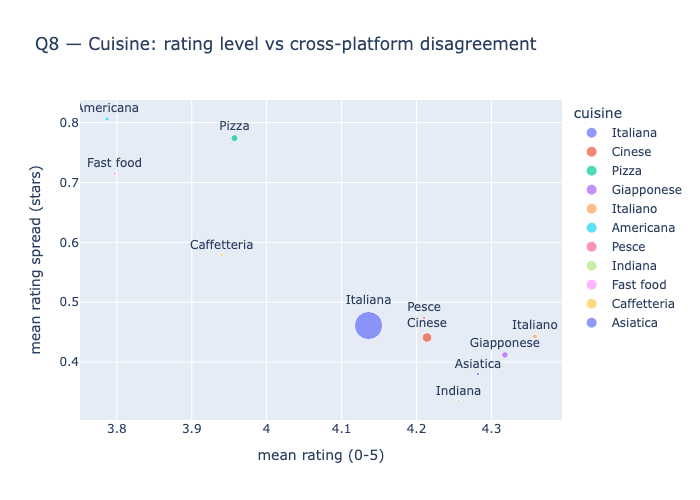

,cuisine,restaurants,mean_rating,multi_platform,mean_range
0,Italiana,2233,4.136,2229,0.461
1,Cinese,262,4.214,262,0.441
2,Pizza,144,3.957,144,0.774
3,Giapponese,125,4.318,124,0.412
4,Italiano,71,4.358,68,0.443
5,Americana,53,3.787,53,0.806
6,Pesce,38,4.210,38,0.474
7,Indiana,34,4.256,34,0.335
8,Fast food,34,3.797,34,0.715
9,Caffetteria,34,3.940,34,0.579


In [27]:
q8 = publish(run(queries.q8_cuisine(top_n=15, min_restaurants=30)), "q8_cuisine_consistency",
             "Q8 — Mean rating and cross-platform spread by primary cuisine.")
fig = px.scatter(q8, x="mean_rating", y="mean_range", size="restaurants", color="cuisine",
                 text="cuisine",
                 labels={"mean_rating": "mean rating (0-5)", "mean_range": "mean rating spread (stars)"},
                 title="Q8 — Cuisine: rating level vs cross-platform disagreement")
fig.update_traces(textposition="top center")
fig.show()
q8

**Answer (Q8):** Rating level and consistency **do vary by cuisine**. High-throughput,
broad-appeal categories (e.g. pizza, fast food / American) show the widest cross-platform
disagreement and lower mean ratings, while cuisines like Japanese sit higher-rated and more
consistent — see `q8_cuisine_consistency`.

## Q9 — Do pricier restaurants rate higher or more consistently? *(extended)*

Uses the normalized `price_tier` (1 = cheapest … 4 = most expensive), derived from
Tripadvisor's band, Google's level, or TheFork's average EUR price.

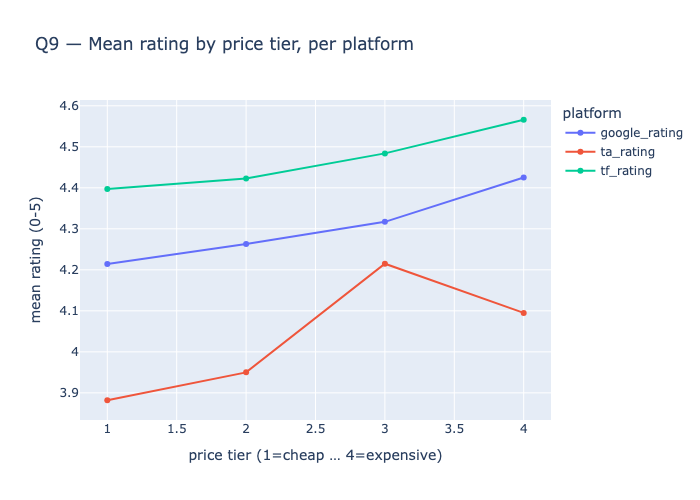

,price_tier,restaurants,google_rating,ta_rating,tf_rating,mean_rating,mean_range
0,1,2262,4.214,3.882,4.397,4.123,0.515
1,2,3120,4.263,3.950,4.423,4.166,0.469
2,3,83,4.317,4.215,4.484,4.332,0.379
3,4,232,4.425,4.095,4.566,4.295,0.447


In [28]:
q9 = publish(run(queries.q9_price_tier()), "q9_price_vs_rating",
             "Q9 — Per-platform rating and cross-platform spread by price tier.")
long = q9.melt(id_vars="price_tier", value_vars=["google_rating", "ta_rating", "tf_rating"],
               var_name="platform", value_name="rating")
fig = px.line(long, x="price_tier", y="rating", color="platform", markers=True,
              labels={"price_tier": "price tier (1=cheap … 4=expensive)", "rating": "mean rating (0-5)"},
              title="Q9 — Mean rating by price tier, per platform")
fig.show()
q9

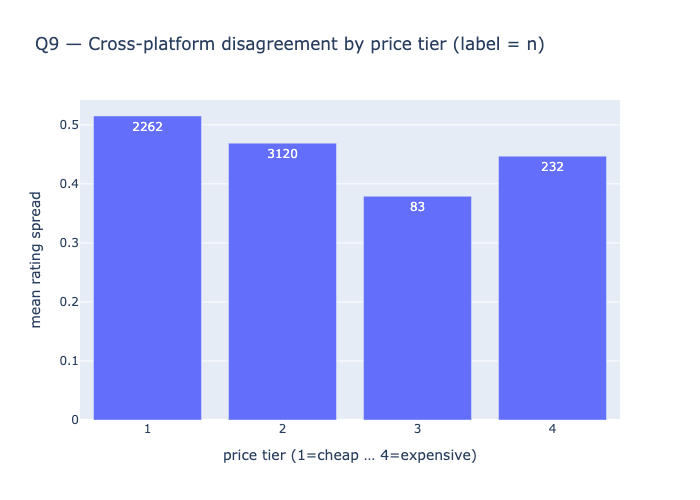

In [29]:
fig = px.bar(q9, x="price_tier", y="mean_range", text="restaurants",
             labels={"price_tier": "price tier (1=cheap … 4=expensive)", "mean_range": "mean rating spread"},
             title="Q9 — Cross-platform disagreement by price tier (label = n)")
fig.show()

**Answer (Q9):** Higher price tiers tend to be **rated higher and disagree less** —
`mean_rating` rises and `mean_range` falls toward the pricier tiers (with the caveat that
the most expensive tiers are small samples). Pricier venues appear to offer a more
consistent, better-regarded experience across platforms.

## Q10 — Are multi-platform restaurants rated differently? (selection effect) *(extended)*

Tests whether simply *being listed on more platforms* is associated with higher ratings and
more reviews — a visibility/selection effect — using Google's rating as the common yardstick
(present for every venue).

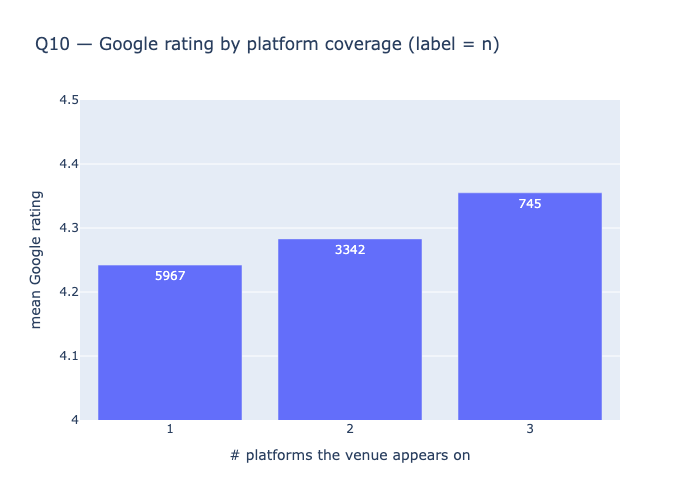

,platform_count,restaurants,mean_google_rating,median_google_reviews
0,1,5967,4.242,83.0
1,2,3342,4.283,371.0
2,3,745,4.355,548.0


In [30]:
q10a = publish(run(queries.q10_rating_by_coverage()), "q10_rating_by_coverage",
               "Q10 — Google rating and review volume by number of platforms a venue is on.")
fig = px.bar(q10a, x="platform_count", y="mean_google_rating", text="restaurants",
             labels={"platform_count": "# platforms the venue appears on", "mean_google_rating": "mean Google rating"},
             title="Q10 — Google rating by platform coverage (label = n)")
fig.update_yaxes(range=[4.0, 4.5])
fig.show()
q10a

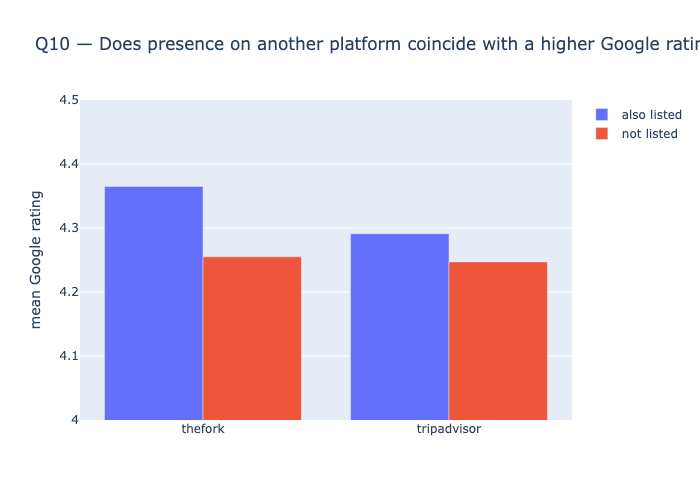

,other_platform,bucket,restaurants,mean_google_rating,median_google_reviews
0,thefork,also listed,908,4.365,484.0
1,thefork,not listed,9146,4.255,154.0
2,tripadvisor,also listed,3924,4.291,409.0
3,tripadvisor,not listed,6130,4.247,85.0


In [31]:
q10b = publish(run(queries.q10_rating_by_presence()), "q10_rating_by_presence",
               "Q10 — Google rating/volume by presence on each other platform.")
fig = px.bar(q10b, x="other_platform", y="mean_google_rating", color="bucket", barmode="group",
             labels={"other_platform": "", "mean_google_rating": "mean Google rating", "bucket": ""},
             title="Q10 — Does presence on another platform coincide with a higher Google rating?")
fig.update_yaxes(range=[4.0, 4.5])
fig.show()
q10b

**Answer (Q10):** Yes — there is a clear **selection effect**. Venues listed on more
platforms have higher Google ratings and *far* more reviews (median Google reviews rise
steeply with coverage), and venues also present on TheFork/Tripadvisor out-rate those that
are not. Multi-platform presence is a marker of established, popular restaurants — a
confounder worth keeping in mind for the consistency findings.

## Q11 — Does visual content (photos) track popularity or rating? *(extended)*

Correlates each platform's photo count with its review volume and rating.

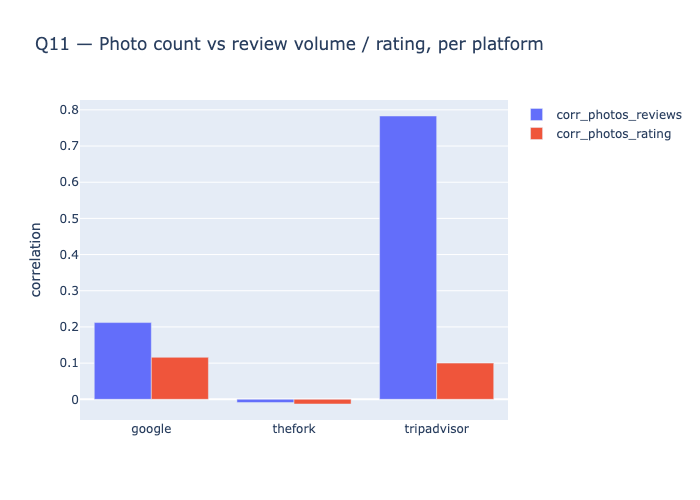

,platform,venues,corr_photos_reviews,corr_photos_rating
0,google,10054,0.212,0.116
1,thefork,908,-0.009,-0.013
2,tripadvisor,3282,0.783,0.100


In [32]:
q11 = publish(run(queries.q11_photo_correlations()), "q11_photo_correlations",
              "Q11 — Correlation of photo count with review volume and rating, per platform.")
fig = px.bar(q11, x="platform", y=["corr_photos_reviews", "corr_photos_rating"], barmode="group",
             labels={"value": "correlation", "platform": "", "variable": ""},
             title="Q11 — Photo count vs review volume / rating, per platform")
fig.show()
q11

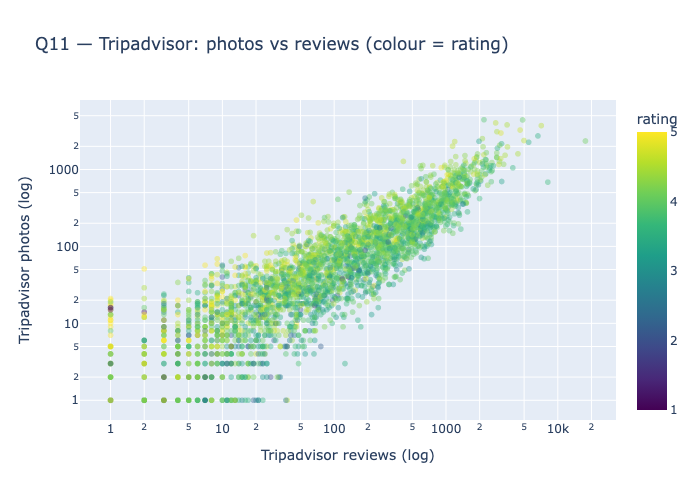

In [33]:
pr = run(queries.q11_photo_rows("tripadvisor"))
fig = px.scatter(pr, x="reviews", y="photos", color="rating", log_x=True, log_y=True,
                 opacity=0.4, color_continuous_scale="Viridis",
                 labels={"reviews": "Tripadvisor reviews (log)", "photos": "Tripadvisor photos (log)", "rating": "rating"},
                 title="Q11 — Tripadvisor: photos vs reviews (colour = rating)")
fig.show()

**Answer (Q11):** Photo richness tracks **popularity more than quality**. Photo count
correlates positively with review volume — strongly on Tripadvisor, moderately on Google —
but only weakly with rating (`q11_photo_correlations`). Visual content is a proxy for how
busy/established a venue is, not how good it is rated.

---
### Exports & viewing the charts

Every section wrote its result table to `report/final/tables/` as `.csv` and a booktabs
`.tex` table, ready to `\\input{}` into the final LaTeX report. Re-running regenerates them.

**Charts render as static images by default.** This is intentional so they display in VS
Code, in **GitHub's notebook viewer (which strips JavaScript — interactive Plotly never
shows there)**, and in the exported HTML. Requires the `kaleido` package (in the `analysis`
extra).

**Standalone static HTML report:**

```bash
uv run jupyter nbconvert --to html notebooks/research_questions_analysis.ipynb --output-dir report/final
```

**Interactive HTML** (zoom/pan/hover, for viewing in a browser — not GitHub):

```bash
DATAMAN_PLOTLY_RENDERER=notebook_connected \\
  uv run jupyter nbconvert --to html --execute notebooks/research_questions_analysis.ipynb --output-dir report/final
```